In [8]:
from quroctet import calc_roctet
from quroctet.utils import auroc
from numpy import arange
import polars as pl
from plotnine import (ggplot, aes, geom_line)

In [9]:
from quroctet import curves, scores
import numpy as np
from numpy.random import uniform, binomial

def _gen_scorebins_to_scores(
    df_scorebins: pl.DataFrame
) -> pl.DataFrame:

    # TODO: validation df_scorebins, seeds

    def _gen_scores_arr(n_pos:int, n_neg:int) -> np.ndarray:

        more = 1 if n_pos >= n_neg else 0 
        xtra = np.repeat(more, abs(n_pos-n_neg))
        base = np.tile([0,1], min(n_pos,n_neg))
        out = np.append(base, xtra)
        return out

    df_scores = (
        df_scorebins
        .with_columns(
            score = pl.struct('score_min','score_max','n').map_elements(
                function = lambda z: sorted(
                                        uniform(low = z['score_min'],
                                             high = z['score_max'],
                                             size = z['n']).tolist()
                                             ),
                return_dtype = pl.List(pl.Float64)
            ),
            target = pl.struct('n','n_pos').map_elements(
                function = lambda z: binomial(n = 1,
                                              p = z['n_pos'] / z['n'],
                                              size = z['n']).tolist(),
                return_dtype = pl.List(pl.Int64)
            ),
            #target = pl.struct('n_neg','n_pos').map_elements(
            #    function = lambda d: _gen_scores_arr(d['n_pos'],d['n_neg']),
            #    return_dtype = pl.List(pl.Int64)).tolist()
            )
        )
    return df_scores.explode('score','target')

df_roc = curves._gen_roc(3,2,100)
df_sb = scores._gen_roc_to_scorebins(df_roc, 50000, 50000)
df_sc = _gen_scorebins_to_scores(df_sb)
df_sc

score_min,score_max,n_pos,n_neg,n,score,target
f64,f64,i64,i64,i64,f64,i64
0.989899,1.0,0,505,505,0.989926,0
0.989899,1.0,0,505,505,0.989956,0
0.989899,1.0,0,505,505,0.989958,0
0.989899,1.0,0,505,505,0.989999,0
0.989899,1.0,0,505,505,0.990022,0
…,…,…,…,…,…,…
0.0,0.010101,30,505,535,0.010031,0
0.0,0.010101,30,505,535,0.010043,0
0.0,0.010101,30,505,535,0.010044,0


## Data Generation

In [10]:
# generate datasets
dfs = calc_roctet(0.67, n_sets = 10) # 0.82
dfs[0].glimpse()

Rows: 100000
Columns: 7
$ score_min <f64> 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999, 0.998998998998999
$ score_max <f64> 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0
$ n_pos     <i64> 11463, 11463, 11463, 11463, 11463, 11463, 11463, 11463, 11463, 11463
$ n_neg     <i64> 50, 50, 50, 50, 50, 50, 50, 50, 50, 50
$ n         <i64> 11513, 11513, 11513, 11513, 11513, 11513, 11513, 11513, 11513, 11513
$ score     <f64> 0.9989990663090751, 0.9989990829574923, 0.9989991005713763, 0.9989991438171123, 0.9989991448476849, 0.9989992540492306, 0.9989995141462233, 0.9989995300760931, 0.998999641344942, 0.9989996795354812
$ target    <i64> 0, 1, 0, 1, 0, 1, 0, 1, 0, 1



In [11]:
# consolidate to one dataset
df = pl.concat( [d.with_columns(index = i) for i,d in enumerate(dfs)] )

## ROC Summary

In [12]:
# compare AUC values
[ auroc(d['target'].to_numpy(), d['score'].to_numpy()) for d in dfs]

[0.6701,
 0.6701,
 0.6701,
 0.6701,
 0.6701,
 0.6702,
 0.6702,
 0.6703,
 0.6703,
 0.6704]

## ROC Curves

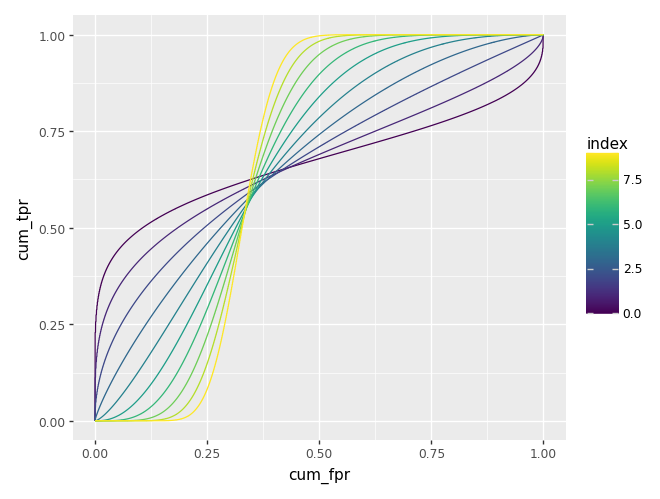

In [13]:
# compute and display roc curve
df_roc = (
    df
    .sort('score', descending=True)
    .with_columns(
        neg_target = 1 - pl.col('target'),
        neg_target_ttl = (1 - pl.col('target')).sum().over('index'),
        pos_target = pl.col('target'),
        pos_target_ttl = pl.col('target').sum().over('index')
        )
    .with_columns(
        cum_fpr = pl.col('neg_target').cum_sum().over('index') / pl.col('neg_target_ttl'),
        cum_tpr = pl.col('pos_target').cum_sum().over('index') / pl.col('pos_target_ttl'),
    )
)

p = ggplot(df_roc)
p += aes(x = 'cum_fpr', y = 'cum_tpr', color = 'index', group = 'index')
p += geom_line()
p

## Lift Charts

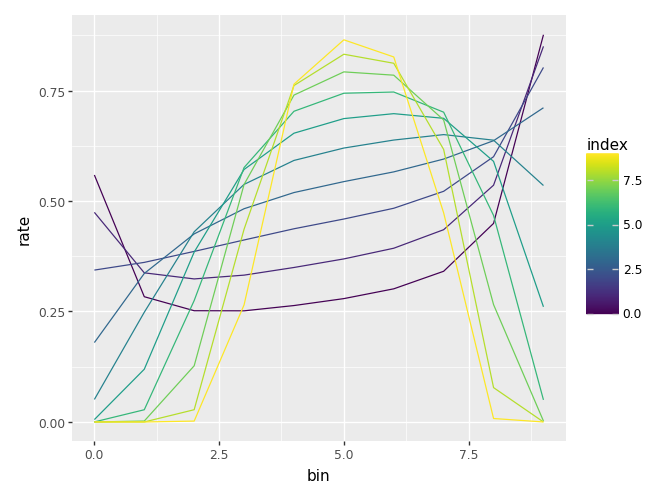

In [ ]:
# visualize lift curves
df = pl.concat( [d.with_columns(index = i) for i,d in enumerate(dfs)] )
df_lift = (
    df
    .group_by( 'index', 
               bin = pl.col('score').qcut(10, labels = arange(10).astype(str)).cast(pl.String).cast(pl.Int16) 
             )
    .agg( rate = pl.col('target').mean() )
)
p = ggplot(df_lift)
p += aes(x = 'bin', y = 'rate', color = 'index', group = 'index')
p += geom_line()
p